# Olist Delivery Delay Risk

This notebook is the first exploratory pass for the project.

## Questions
1. How common are late deliveries in the delivered-order subset?
2. Which purchase-time patterns seem associated with late deliveries?
3. Which features look promising before training a first model?

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.io import load_olist_tables
from src.data.prepare import build_modeling_frame
from src.features.engineering import build_model_dataset

sns.set_theme(style="whitegrid")

In [6]:
data_dir = ROOT / "data" / "raw"
tables = load_olist_tables(data_dir)
modeling_frame = build_modeling_frame(tables)
dataset = build_model_dataset(modeling_frame)

print(f"Rows in modeling frame: {len(modeling_frame):,}")
print(f"Rows in model dataset: {len(dataset):,}")
print(f"Late-delivery rate: {dataset['is_late'].mean():.2%}")
dataset.head()

Rows in modeling frame: 99,441
Rows in model dataset: 96,470
Late-delivery rate: 8.11%


,order_id,item_count,total_price,total_freight_value,unique_sellers,payment_value,payment_installments_max,payment_type_count,avg_product_weight_g,avg_product_volume_cm3,...,purchase_month,purchase_day,is_weekend_purchase,price_per_item,freight_to_price_ratio,seller_customer_same_state,customer_state,payment_type_mode,primary_seller_state,is_late
3,bfbd0f9bdef84302105ad712db648a6c,3.0,134.97,8.49,1.0,NaN,NaN,NaN,1000.0,4096.0,...,9,15,0,44.99,0.062903,0,SP,NaN,PR,1
5,3b697a20d9e427646d92567910af6d57,1.0,29.90,15.56,1.0,45.46,1.0,1.0,300.0,4096.0,...,10,3,0,29.90,0.520401,0,SP,boleto,PR,0
6,be5bc2f0da14d8071e2d45451ad119d9,1.0,21.90,17.19,1.0,39.09,1.0,1.0,400.0,4096.0,...,10,3,0,21.90,0.784932,0,RS,boleto,SP,0
8,a41c8759fbe7aab36ea07e038b2d4465,1.0,36.49,17.24,1.0,53.73,1.0,1.0,767.0,4160.0,...,10,3,0,36.49,0.472458,0,RS,boleto,SP,0
9,d207cc272675637bfed0062edffd0818,1.0,119.90,13.56,1.0,133.46,6.0,1.0,2050.0,14960.0,...,10,3,0,119.90,0.113094,1,SP,credit_card,SP,0


## Plot 1: Target balance
Use this to confirm the class imbalance before picking metrics.

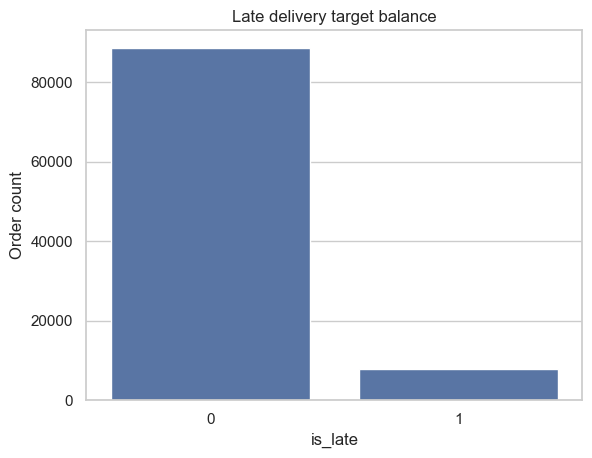

In [7]:
ax = sns.countplot(data=dataset, x="is_late")
ax.set(title="Late delivery target balance", xlabel="is_late", ylabel="Order count")
plt.show()

## Plot 2: Late rate by customer state
Limit to the most common states so the chart stays readable.

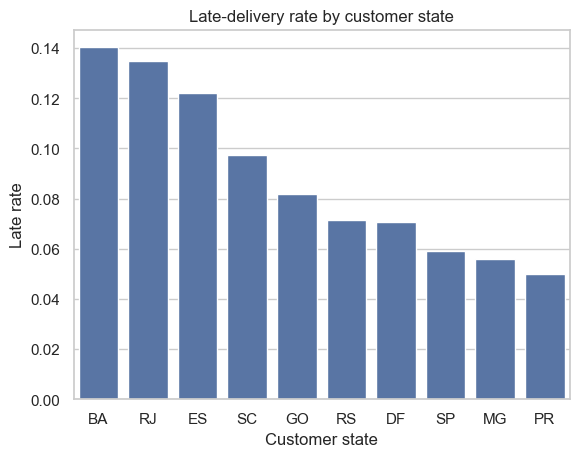

In [8]:
top_states = dataset['customer_state'].value_counts().head(10).index
state_rates = (
    dataset.loc[dataset['customer_state'].isin(top_states)]
    .groupby('customer_state', as_index=False)['is_late']
    .mean()
    .sort_values('is_late', ascending=False)
)

ax = sns.barplot(data=state_rates, x='customer_state', y='is_late')
ax.set(title='Late-delivery rate by customer state', xlabel='Customer state', ylabel='Late rate')
plt.show()

## Plot 3: Estimated delivery window vs. target
This checks whether tighter promised windows are associated with more delay risk.

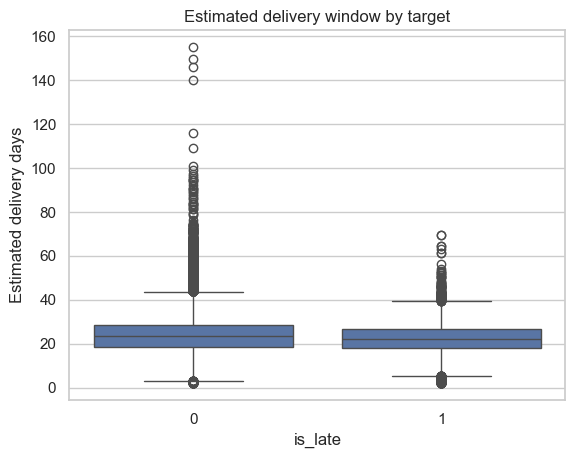

In [9]:
ax = sns.boxplot(data=dataset, x='is_late', y='estimated_delivery_days')
ax.set(title='Estimated delivery window by target', xlabel='is_late', ylabel='Estimated delivery days')
plt.show()

## Plot 4: Payment type and late rate
This can surface simple operational or customer-behavior patterns.

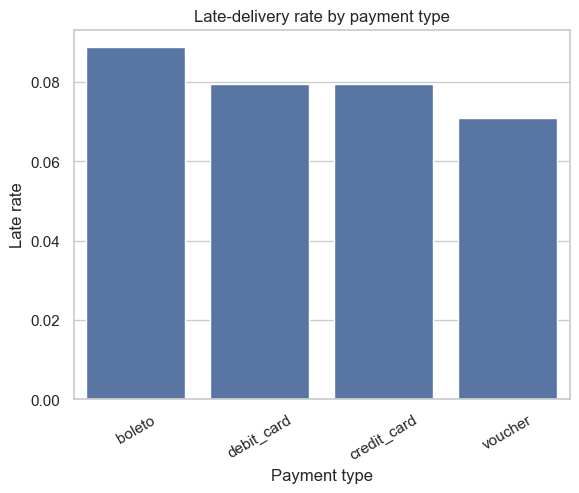

In [10]:
payment_rates = (
    dataset.groupby('payment_type_mode', as_index=False)['is_late']
    .mean()
    .sort_values('is_late', ascending=False)
)

ax = sns.barplot(data=payment_rates, x='payment_type_mode', y='is_late')
ax.set(title='Late-delivery rate by payment type', xlabel='Payment type', ylabel='Late rate')
plt.xticks(rotation=30)
plt.show()

## Plot 5: Price distribution by target
This is a quick way to see whether larger baskets behave differently.

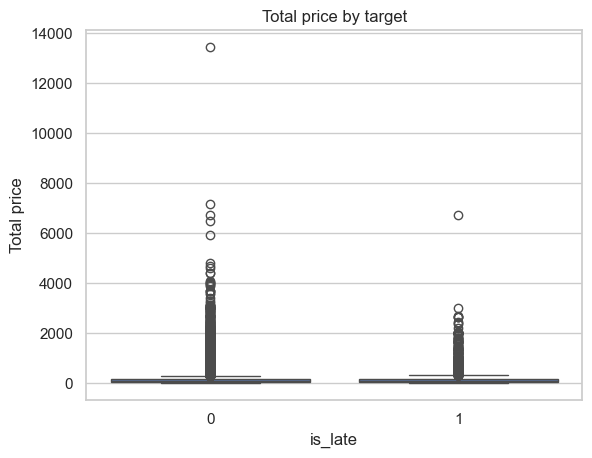

In [11]:
ax = sns.boxplot(data=dataset, x='is_late', y='total_price')
ax.set(title='Total price by target', xlabel='is_late', ylabel='Total price')
plt.show()

## Notes to write after the first pass
- What is the late-delivery base rate?
- Which segments look riskier?
- Which features should definitely stay for the first model?
- Which features should be excluded because of leakage or low trust?